## Data Analytics

### Chapter 11: Data Visualization (Categorical Plots)

Data Visualization is the practice of representing data using visual elements such as charts, graphs, maps, and diagrams. By converting numerical and categorical data into visual form, complex information becomes easier to understand and interpret.

The primary purpose of data visualization is to simplify large datasets into meaningful visual insights, allowing users to quickly identify patterns, trends, relationships, and outliers that may not be obvious from raw data alone.

#### Generate Synthetic Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
n = 200

df = pd.DataFrame({
    "Student ID": [f"S{i:03d}" for i in range(1, n+1)],
    "Age": np.random.randint(18, 24, n),
    "Height": np.random.normal(170, 8, n).round(1),
    "Weight": np.random.normal(65, 12, n).round(1),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Major": np.random.choice(["AI", "IT", "CSC", "SE"], n),
    "GPA": np.round(np.random.uniform(2.0, 4.0, n), 2)
})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student ID  200 non-null    object 
 1   Age         200 non-null    int64  
 2   Height      200 non-null    float64
 3   Weight      200 non-null    float64
 4   Gender      200 non-null    object 
 5   Major       200 non-null    object 
 6   GPA         200 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 11.1+ KB


### 11.0. Categorical Plots

Categorical plots are designed to summarize and compare values across different categories. They are among the most commonly used visualizations in exploratory data analysis because they allow us to quickly compare groups, identify trends, and communicate results clearly.

#### 11.1. Bar Chart

A **bar chart** displays aggregated values for different categories using rectangular bars. The height (or length) of each bar represents the magnitude of the corresponding category, making it one of the simplest and most effective charts for comparing categorical data.

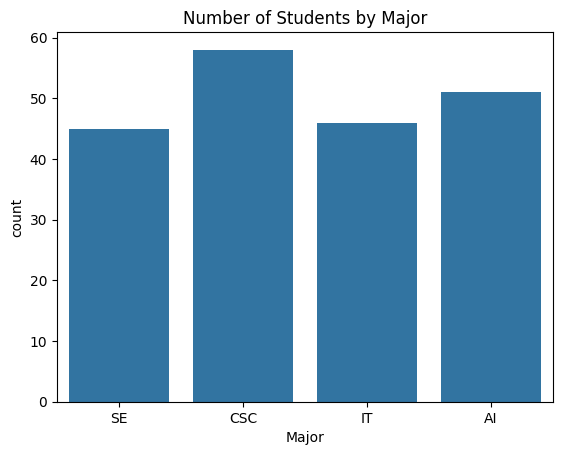

In [3]:
# Student Count by Major
sns.countplot(data=df, x="Major")
plt.title("Number of Students by Major")
plt.show()

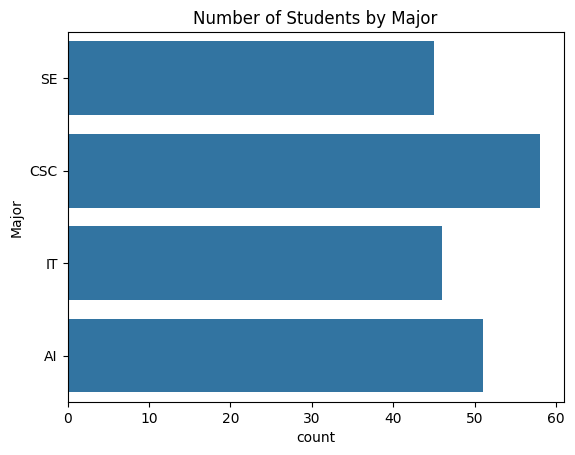

In [4]:
# Horizontal Bar Chart
sns.countplot(data=df, y="Major")
plt.title("Number of Students by Major")
plt.show()

#### 11.2. Clustered Bar Chart

A **clustered bar chart** (also called a grouped bar chart) compares multiple groups within each category by placing bars side-by-side. This makes it easy to compare subgroups while still preserving the overall category structure.

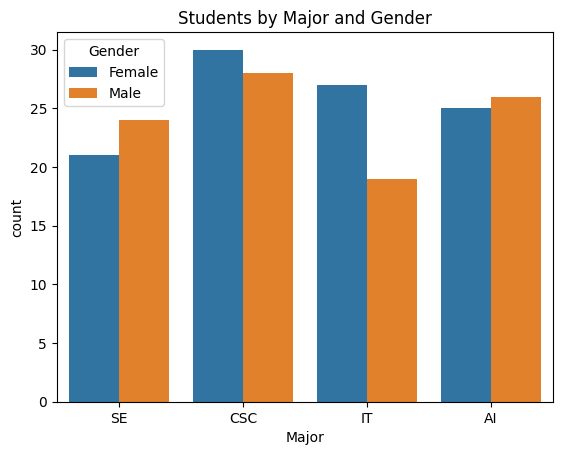

In [5]:
# we can compare the number of male and female students within each major.
sns.countplot(data=df, x="Major", hue="Gender")
plt.title("Students by Major and Gender")
plt.show()

#### 11.3. Stacked Bar Chart

A **stacked bar chart** displays both the total value of each category and the contribution of its individual components. Instead of placing bars side-by-side, each subgroup is stacked vertically, making it easier to visualize proportions within the total.

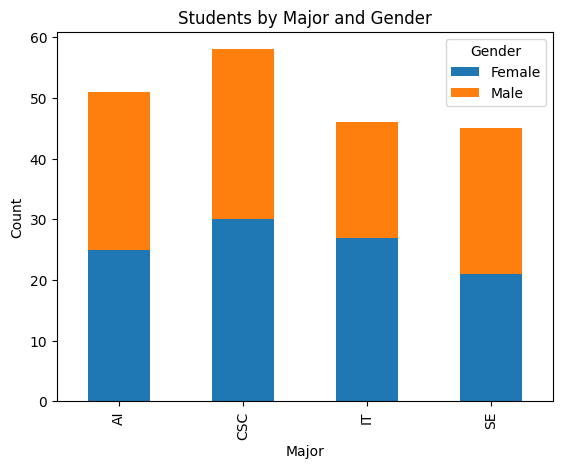

In [ ]:
major_gender = pd.crosstab(df["Major"], df["Gender"])
major_gender.plot(kind="bar", stacked=True)

plt.title("Students by Major and Gender")
plt.ylabel("Count")
plt.show()

#### 11.4. Point Plot

A **point plot** summarizes a numerical variable by displaying its average value for each category. Each point represents the mean of the observations in a category, while connecting lines help visualize differences or trends between categories.

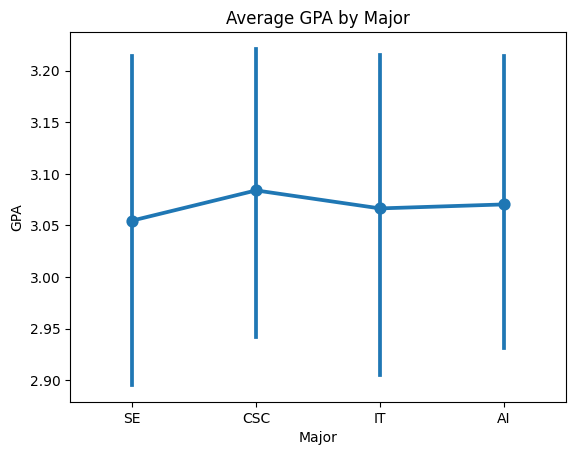

In [7]:
# Average GPA by Major
sns.pointplot(data=df, x="Major", y="GPA")

plt.title("Average GPA by Major")
plt.show()

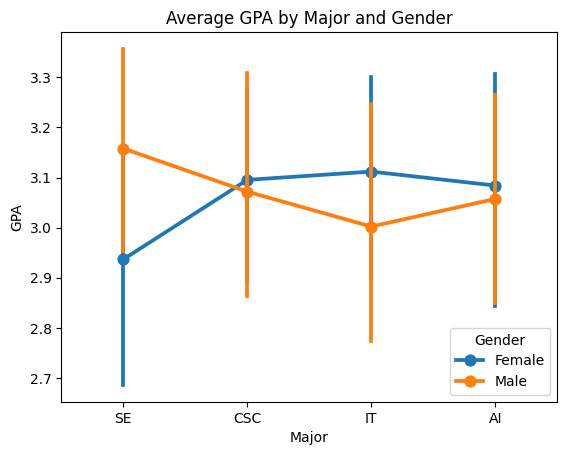

In [8]:
# Average GPA by Major and Gender
sns.pointplot(
    data=df,
    x="Major",
    y="GPA",
    hue="Gender"
)

plt.title("Average GPA by Major and Gender")
plt.show()

#### 11.5. Line Chart

A **line chart** displays data points connected by straight lines, making it ideal for visualizing trends over time or another continuous sequence. While line charts are most commonly used for time-series data, they can also illustrate changes across ordered categories.

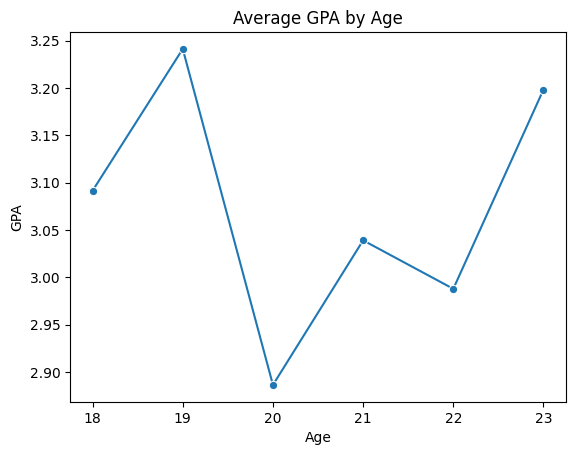

In [9]:
# we want to observe how the average GPA changes with age.
avg_gpa = (
    df.groupby("Age")["GPA"]
      .mean()
      .reset_index()
)

sns.lineplot(data=avg_gpa, x="Age", y="GPA", marker="o")

plt.title("Average GPA by Age")
plt.show()

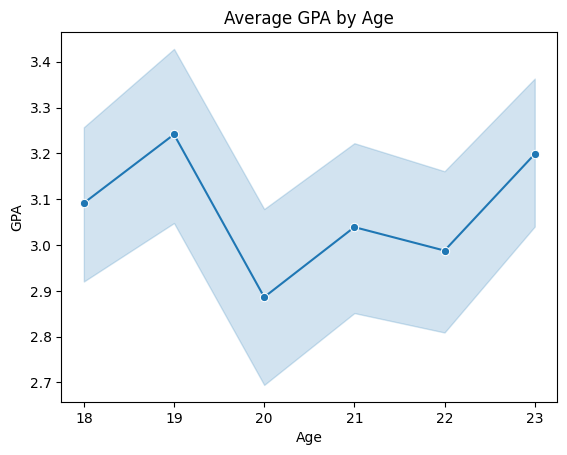

In [11]:
# Seaborn can perform the aggregation automatically
sns.lineplot(
    data=df,
    x="Age",
    y="GPA",
    estimator="mean",
    marker="o"
)

plt.title("Average GPA by Age")
plt.show()

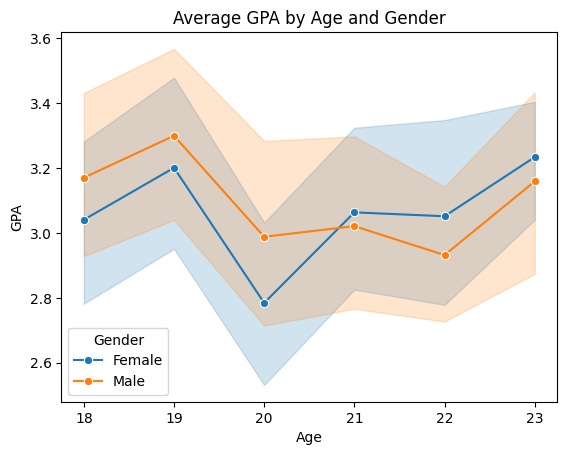

In [12]:
#  Average GPA by Age and Gender
sns.lineplot(
    data=df,
    x="Age",
    y="GPA",
    hue="Gender",
    estimator="mean",
    marker="o"
)

plt.title("Average GPA by Age and Gender")
plt.show()

#### 11.6. Area Chart

An **area chart** is similar to a line chart but fills the area beneath the line, making it easier to visualize cumulative values and overall trends. Area charts are particularly useful for showing how quantities change over time while emphasizing the magnitude of the values.

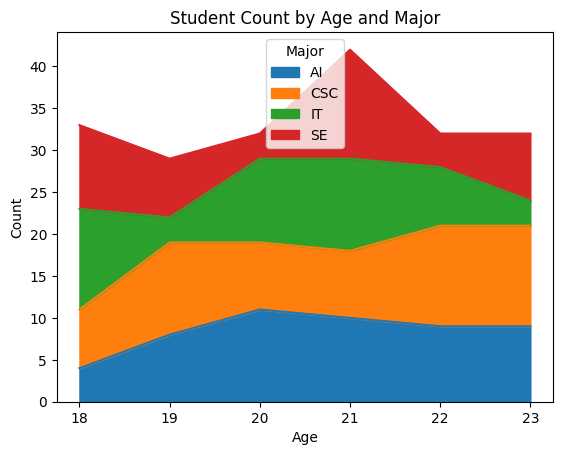

In [13]:
# Normal Area Chart
major_age = (
    df.groupby(["Age", "Major"])
      .size()
      .unstack(fill_value=0)
)

major_age.plot.area()

plt.title("Student Count by Age and Major")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

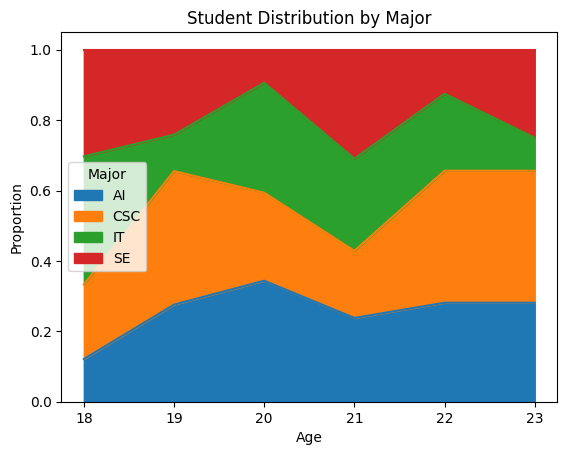

In [14]:
# 100% Area Chart
major_age_percent = major_age.div(
    major_age.sum(axis=1),
    axis=0
)

major_age_percent.plot.area()

plt.title("Student Distribution by Major")
plt.xlabel("Age")
plt.ylabel("Proportion")
plt.show()

#### 11.7. Pie Chart

A **pie chart** represents how individual categories contribute to a whole. The entire circle represents **100%**, while each slice corresponds to the proportion of a category.

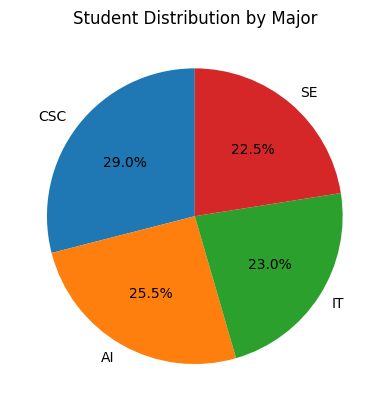

In [15]:
major_count = df["Major"].value_counts()

plt.pie(
    major_count,
    labels=major_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student Distribution by Major")
plt.show()

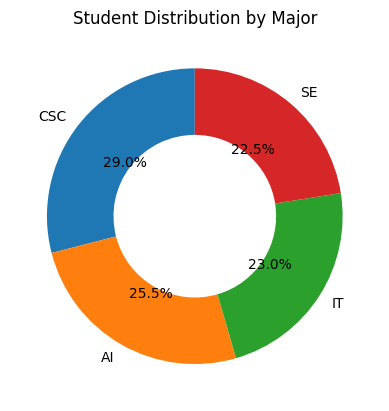

In [16]:
# A donut chart is a variation of the pie chart with the center removed.
major_count = df["Major"].value_counts()

plt.pie(
    major_count,
    labels=major_count.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.45}
)

plt.title("Student Distribution by Major")
plt.show()